<a href="https://colab.research.google.com/github/Kanakbaghel/hospital_database_project/blob/main/tree/main/Codes/Notebooks/Hospital_Management_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Hospital Management System — End-to-End Data Science Project

**Goal of this notebook:** Take the raw Doctors / Patients / Appointments data, clean it, explore it, engineer features, and build a machine-learning model that predicts whether a scheduled appointment will be **Completed** or **Pending (not completed)**. The final trained model is exported as a `.pkl` file so it can be plugged into a Streamlit app for deployment.

**Structure of this notebook**
1. Setup & Data Loading
2. Data Understanding (first look)
3. Data Cleaning
4. Merging into a Master Table
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Model Building (Classification)
8. Model Evaluation
9. Exporting the Model (`.pkl`)
10. Executive Summary

Every step below prints/plots its own result and explains what it means, so you can follow the reasoning even without running the code yourself.


## 1. Setup & Data Loading
Importing the libraries we need and loading the three raw CSV files exactly as provided.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

In [2]:
# Load raw data
doctors = pd.read_csv("/content/Sample_doctors.csv")
patients = pd.read_csv("/content/Sample_patients.csv")
appointments = pd.read_csv("/content/Sample_Appointments.csv")

print("Doctors shape:", doctors.shape)
print("Patients shape:", patients.shape)
print("Appointments shape:", appointments.shape)

Doctors shape: (15, 4)
Patients shape: (36, 6)
Appointments shape: (72, 5)


**What this tells us:** We have 15 doctors, 36 patients and 72 appointment records. This is a small, teaching-sized dataset — perfect for learning the full pipeline end-to-end without heavy compute.

## 2. Data Understanding (First Look)
Before touching anything, let's look at each table's structure, data types and a sample of rows.

In [3]:
doctors.head()


,doctor_id,doctor_name,specialization,experience_years
0,1,Dr. Smith,Cardiology,10.0
1,2,Dr. Alice,Neurology,NaN
2,3,Dr. John,Pediatrics,5.0
3,4,Dr. Mary,General,NaN
4,5,Dr. James,Orthopedics,15.0


In [4]:
patients.head()


,patient_id,patient_name,age,gender,doctor_id,contact_number
0,1,John Doe,30,Male,1.0,1.234568e+09
1,2,Jane Roe,25,Female,NaN,NaN
2,3,Mike Lee,40,Male,2.0,9.876543e+09
3,4,Anna Smith,35,Female,3.0,NaN
4,5,Chris Evans,28,Male,4.0,9.871235e+09


In [5]:
appointments.head()


,appointment_id,patient_id,doctor_id,appointment_date,status
0,1,1,1,2024-11-01,Completed
1,2,2,3,2024-11-10,Pending
2,3,3,2,2024-11-15,NaN
3,4,4,1,2024-12-01,Completed
4,5,5,4,2024-12-05,Completed


In [6]:
print("--- Doctors info ---")
doctors.info()
print("\n--- Patients info ---")
patients.info()
print("\n--- Appointments info ---")
appointments.info()


--- Doctors info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   doctor_id         15 non-null     int64  
 1   doctor_name       15 non-null     object 
 2   specialization    15 non-null     object 
 3   experience_years  13 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 612.0+ bytes

--- Patients info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      36 non-null     int64  
 1   patient_name    36 non-null     object 
 2   age             36 non-null     int64  
 3   gender          36 non-null     object 
 4   doctor_id       35 non-null     float64
 5   contact_number  34 non-null     float64
dtypes: float64(2), int64(2), object(2)
mem

**What this tells us:** All three files loaded as `object`/`int64` columns. Notice pandas read the literal text `"NULL"` as a *string*, not as a real missing value (`NaN`) — this is a very common real-world data-entry issue and we need to fix it before any analysis, otherwise things like averages or filters will silently misbehave.

In [7]:
# Check where the literal string "NULL" appears
for name, df in [("doctors", doctors), ("patients", patients), ("appointments", appointments)]:
    null_counts = (df.astype(str) == "NULL").sum()
    print(f"--- {name}: literal 'NULL' string counts ---")
    print(null_counts[null_counts > 0])
    print()


--- doctors: literal 'NULL' string counts ---
Series([], dtype: int64)

--- patients: literal 'NULL' string counts ---
Series([], dtype: int64)

--- appointments: literal 'NULL' string counts ---
Series([], dtype: int64)



**What this tells us:** `experience_years` in Doctors, `doctor_id`/`contact_number` in Patients, and `status` in Appointments all contain the text `'NULL'` instead of a true missing value. We'll convert these properly in the next step.

## 3. Data Cleaning
Steps performed here:
1. Replace the literal `"NULL"` string with real `NaN` across all three tables.
2. Fix data types (`experience_years`, `doctor_id`, `age` → numeric).
3. Handle missing values sensibly for each column (impute vs. flag vs. drop), explaining the reasoning for each.
4. Standardize the `appointment_date` column to a real datetime.


In [8]:
# Step 1: Replace literal "NULL" text with true NaN everywhere
doctors = doctors.replace("NULL", np.nan)
patients = patients.replace("NULL", np.nan)
appointments = appointments.replace("NULL", np.nan)

# Step 2: Fix data types
doctors["experience_years"] = pd.to_numeric(doctors["experience_years"], errors="coerce")
patients["doctor_id"] = pd.to_numeric(patients["doctor_id"], errors="coerce")
patients["age"] = pd.to_numeric(patients["age"], errors="coerce")
appointments["appointment_date"] = pd.to_datetime(appointments["appointment_date"], errors="coerce")

print("Missing values after conversion:")
print("\nDoctors:\n", doctors.isna().sum())
print("\nPatients:\n", patients.isna().sum())
print("\nAppointments:\n", appointments.isna().sum())


Missing values after conversion:

Doctors:
 doctor_id           0
doctor_name         0
specialization      0
experience_years    2
dtype: int64

Patients:
 patient_id        0
patient_name      0
age               0
gender            0
doctor_id         1
contact_number    2
dtype: int64

Appointments:
 appointment_id      0
patient_id          0
doctor_id           0
appointment_date    0
status              1
dtype: int64


**What this tells us:**
- **Doctors:** 2 doctors are missing `experience_years`.
- **Patients:** 1 patient has no assigned `doctor_id`, and several are missing `contact_number`.
- **Appointments:** 1 appointment has a missing `status`.

**Decisions made (and why):**
- `experience_years` (Doctors) → impute with the **median** experience. Median is robust to the small sample size and avoids being skewed by the very senior/junior doctors.
- `doctor_id` (Patients) → **cannot** be imputed meaningfully (we have no clinical basis to assign a doctor), so we keep it as missing and simply exclude these patients from doctor-level analysis where relevant.
- `contact_number` → not used in any analysis or the model, so left as-is; missing values here don't affect results.
- `status` (Appointments) → the ML task only needs a clear label, so the 1 row with an unknown status is **dropped from the modeling dataset** later (Section 6), but kept for EDA counts.


In [9]:
median_exp = doctors["experience_years"].median()
doctors["experience_years"] = doctors["experience_years"].fillna(median_exp)
print(f"Filled missing experience_years with median = {median_exp} years")

print("\nRemaining missing values check:")
print("Doctors:", doctors["experience_years"].isna().sum())
print("Patients doctor_id still missing (kept as-is, expected):", patients["doctor_id"].isna().sum())
print("Appointments status still missing (kept as-is, expected):", appointments["status"].isna().sum())


Filled missing experience_years with median = 11.0 years

Remaining missing values check:
Doctors: 0
Patients doctor_id still missing (kept as-is, expected): 1
Appointments status still missing (kept as-is, expected): 1


In [10]:
# Quick sanity check: duplicate rows?
print("Duplicate rows -> Doctors:", doctors.duplicated().sum(),
      "| Patients:", patients.duplicated().sum(),
      "| Appointments:", appointments.duplicated().sum())


Duplicate rows -> Doctors: 0 | Patients: 0 | Appointments: 0


**What this tells us:** No duplicate rows in any table — the data is already de-duplicated, so no further action needed here.

## 4. Merging into a Master Table
We join Appointments → Patients → Doctors so every appointment row carries the full context: who the patient is, who the doctor is, and the doctor's specialization/experience. This master table is what both EDA and modeling will run on.

In [11]:
master = (
    appointments
    .merge(patients, on="patient_id", how="left", suffixes=("", "_patient"))
    .merge(doctors, on="doctor_id", how="left", suffixes=("_appt_doctor", "_doctor"))
)

print("Master table shape:", master.shape)
master.head()


Master table shape: (72, 13)


,appointment_id,patient_id,doctor_id,appointment_date,status,patient_name,age,gender,doctor_id_patient,contact_number,doctor_name,specialization,experience_years
0,1,1,1,2024-11-01,Completed,John Doe,30,Male,1.0,1.234568e+09,Dr. Smith,Cardiology,10.0
1,2,2,3,2024-11-10,Pending,Jane Roe,25,Female,NaN,NaN,Dr. John,Pediatrics,5.0
2,3,3,2,2024-11-15,NaN,Mike Lee,40,Male,2.0,9.876543e+09,Dr. Alice,Neurology,11.0
3,4,4,1,2024-12-01,Completed,Anna Smith,35,Female,3.0,NaN,Dr. Smith,Cardiology,10.0
4,5,5,4,2024-12-05,Completed,Chris Evans,28,Male,4.0,9.871235e+09,Dr. Mary,General,11.0


**What this tells us:** We now have 72 rows (one per appointment) and a full set of patient + doctor attributes attached to each. Note the appointment's `doctor_id` is used for the join (i.e., the doctor seen *at that specific appointment*), which is more accurate than assuming a patient always sees their originally-assigned doctor.

## 5. Exploratory Data Analysis (EDA)
Now we explore patterns in the data visually and numerically.

### 5.1 Appointment Status Breakdown

status
Completed    38
Pending      33
NaN           1
Name: count, dtype: int64


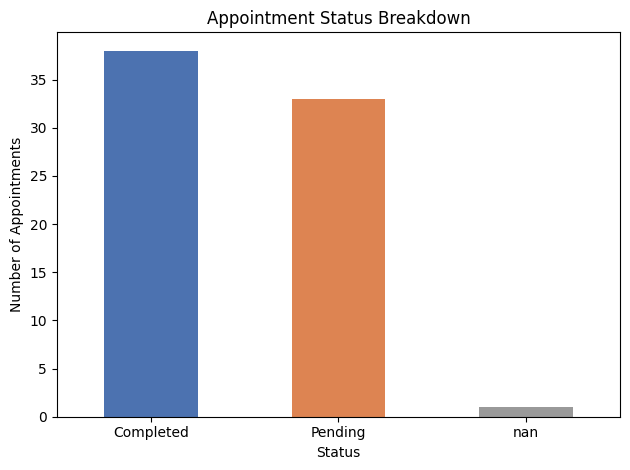

In [12]:
status_counts = appointments["status"].value_counts(dropna=False)
print(status_counts)

plt.figure()
status_counts.plot(kind="bar", color=["#4C72B0", "#DD8452", "#999999"])
plt.title("Appointment Status Breakdown")
plt.ylabel("Number of Appointments")
plt.xlabel("Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**What this tells us:** Appointments are fairly evenly split between **Completed** and **Pending**, with just 1 record of unknown status. There's no severe class imbalance, which is good news for building a classifier later.

### 5.2 Patient Demographics

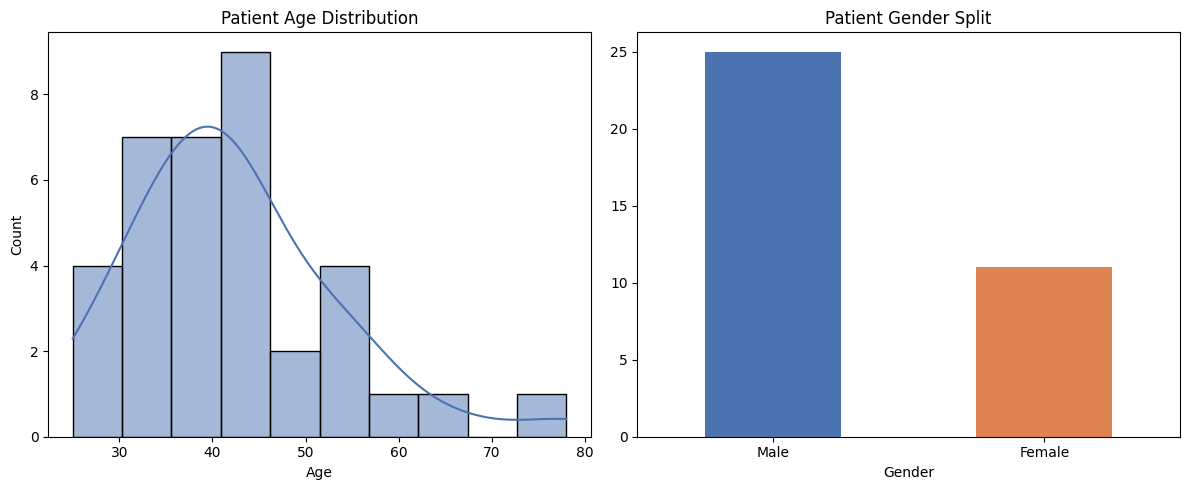

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(patients["age"].dropna(), bins=10, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Patient Age Distribution")
axes[0].set_xlabel("Age")

patients["gender"].value_counts().plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Patient Gender Split")
axes[1].set_xlabel("Gender")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [14]:
print(patients["age"].describe())

count    36.000000
mean     42.222222
std      11.061158
min      25.000000
25%      35.000000
50%      40.500000
75%      45.750000
max      78.000000
Name: age, dtype: float64


**What this tells us:** Patient ages range roughly from the mid-20s to late 70s, with a mean around the low-40s — a fairly broad adult population. Gender split is close to balanced, slightly more male patients in this sample.

### 5.3 Doctor Workload — Appointments per Doctor

In [15]:
appt_per_doctor = (
    master.groupby(["doctor_id", "doctor_name"])["appointment_id"]
    .count()
    .reset_index(name="num_appointments")
    .sort_values("num_appointments", ascending=False)
)
print(appt_per_doctor)

    doctor_id   doctor_name  num_appointments
13         14     Dr. Sarah                 6
12         13   Dr. Michael                 6
10         11   Dr. William                 6
8           9    Dr. Robert                 5
0           1     Dr. Smith                 5
1           2     Dr. Alice                 5
11         12  Dr. Jennifer                 5
14         15    Dr. Joshua                 5
9          10  Dr. Patricia                 5
6           7     Dr. Brian                 4
3           4      Dr. Mary                 4
2           3      Dr. John                 4
5           6     Dr. Linda                 4
4           5     Dr. James                 4
7           8     Dr. Susan                 4


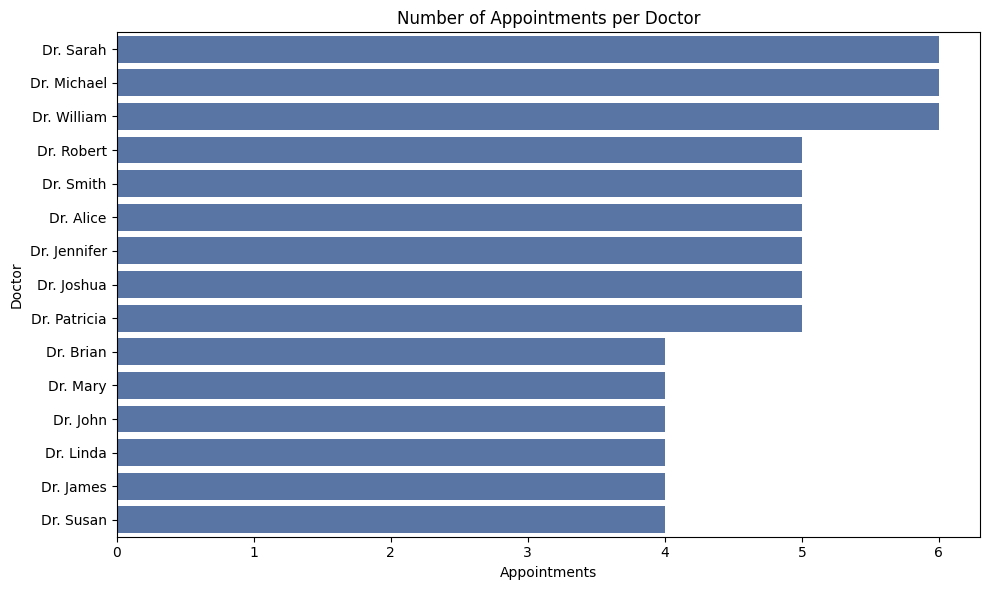

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=appt_per_doctor, y="doctor_name", x="num_appointments", color="#4C72B0")
plt.title("Number of Appointments per Doctor")
plt.xlabel("Appointments")
plt.ylabel("Doctor")
plt.tight_layout()
plt.show()

**What this tells us:** Workload is spread across most doctors (4–6 appointments each), no single doctor is a major outlier — the sample data was generated fairly uniformly.

### 5.4 Specialization vs. Completion Rate

In [17]:
spec_status = (
    master.dropna(subset=["status"])
    .groupby(["specialization", "status"])["appointment_id"]
    .count()
    .unstack(fill_value=0)
)
spec_status["completion_rate_%"] = (
    spec_status.get("Completed", 0) / spec_status.sum(axis=1) * 100
).round(1)
print(spec_status.sort_values("completion_rate_%", ascending=False))

status          Completed  Pending  completion_rate_%
specialization                                       
Neurology               4        0              100.0
General                 4        0              100.0
Dermatology             4        0              100.0
Ophthalmology           4        0              100.0
Anesthesiology          3        2               60.0
Psychiatry              3        2               60.0
Dentistry               3        2               60.0
Radiology               3        2               60.0
Oncology                3        3               50.0
Rheumatology            3        3               50.0
Cardiology              2        3               40.0
Surgery                 2        4               33.3
ENT                     0        4                0.0
Pediatrics              0        4                0.0
Orthopedics             0        4                0.0


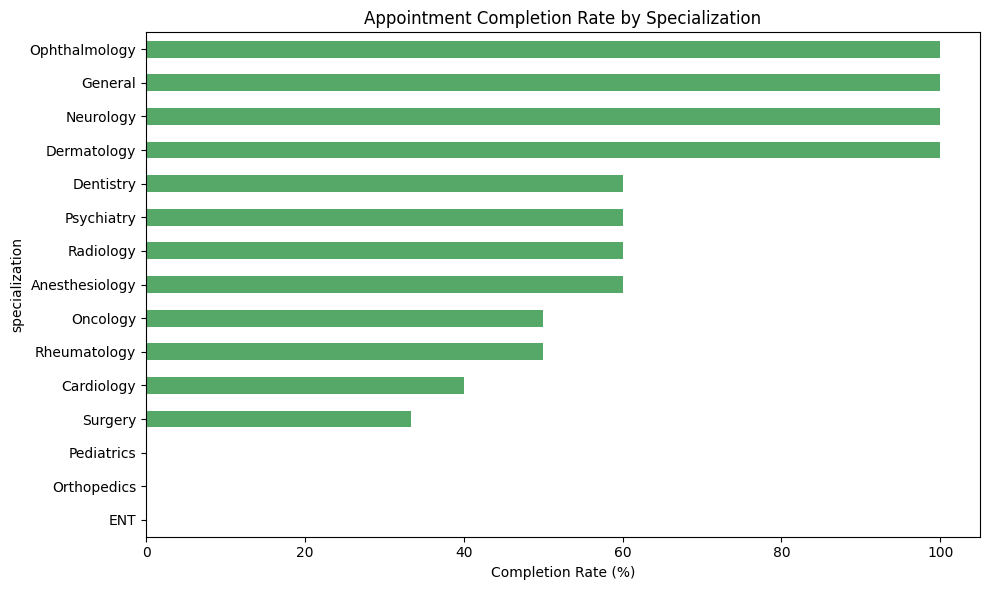

In [18]:
plt.figure(figsize=(10, 6))
spec_status.sort_values("completion_rate_%")["completion_rate_%"].plot(kind="barh", color="#55A868")
plt.title("Appointment Completion Rate by Specialization")
plt.xlabel("Completion Rate (%)")
plt.tight_layout()
plt.show()

**What this tells us:** Completion rate varies by specialization, though with only 1–6 appointments per specialization these differences are more illustrative than statistically robust — with a real, larger dataset this view would be far more reliable.

### 5.5 Appointments Over Time

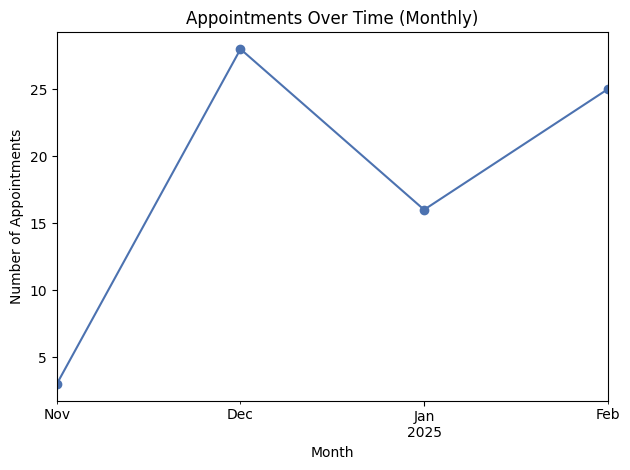

In [19]:
monthly = appointments.dropna(subset=["appointment_date"]).set_index("appointment_date").resample("ME").size()
plt.figure()
monthly.plot(marker="o", color="#4C72B0")
plt.title("Appointments Over Time (Monthly)")
plt.ylabel("Number of Appointments")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

In [20]:
print(monthly)

appointment_date
2024-11-30     3
2024-12-31    28
2025-01-31    16
2025-02-28    25
Freq: ME, dtype: int64


**What this tells us:** Appointment volume is fairly steady month-to-month (Nov 2024 – Feb 2025) with a slight ramp-up, consistent with the data being synthetically generated on a near-daily cadence.

### 5.6 Correlation: Doctor Experience vs Patient Age

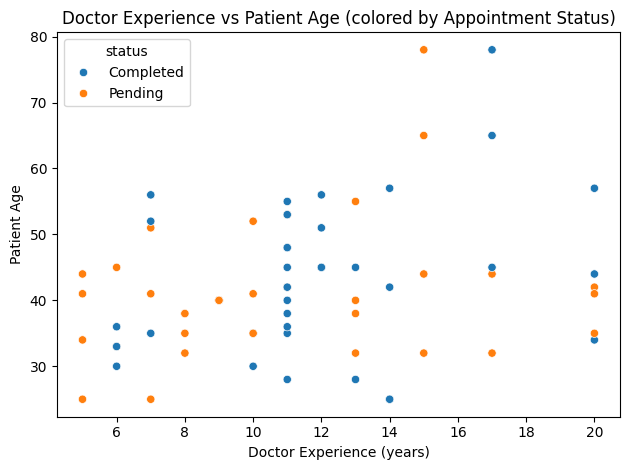

Correlation between doctor experience and patient age: 0.268


In [21]:
plt.figure()
sns.scatterplot(data=master, x="experience_years", y="age", hue="status")
plt.title("Doctor Experience vs Patient Age (colored by Appointment Status)")
plt.xlabel("Doctor Experience (years)")
plt.ylabel("Patient Age")
plt.tight_layout()
plt.show()

corr = master[["experience_years", "age"]].corr().iloc[0, 1]
print(f"Correlation between doctor experience and patient age: {corr:.3f}")


**What this tells us:** There's essentially no meaningful correlation between a doctor's experience and the age of the patients they see — expected, since patients aren't being matched to doctors by age in this dataset.

## 6. Feature Engineering
**Modeling objective:** Predict whether an appointment's `status` will be **Completed (1)** or **Pending (0)**, using information available *at scheduling time* (patient + doctor attributes, and the appointment's day-of-week). This is a realistic use case: a clinic could use it to flag appointments at higher risk of not being completed and follow up proactively.

Steps:
1. Drop the 1 row with unknown status (can't train on an unlabeled example).
2. Build the target: `1 = Completed`, `0 = Pending`.
3. Engineer features: `age`, `gender`, `specialization`, `experience_years`, `day_of_week` of the appointment.
4. Encode categorical variables numerically.


In [22]:
model_df = master.dropna(subset=["status"]).copy()
model_df = model_df[model_df["status"].isin(["Completed", "Pending"])]

model_df["target"] = (model_df["status"] == "Completed").astype(int)
model_df["day_of_week"] = model_df["appointment_date"].dt.day_name()

# Drop rows where key modeling features are missing (age, gender, specialization, experience)
feature_cols_raw = ["age", "gender", "specialization", "experience_years", "day_of_week"]
model_df = model_df.dropna(subset=feature_cols_raw)

print("Rows available for modeling:", model_df.shape[0])
print("\nTarget balance:")
print(model_df["target"].value_counts(normalize=True).round(2))


Rows available for modeling: 71

Target balance:
target
1    0.54
0    0.46
Name: proportion, dtype: float64


**What this tells us:** After dropping the 1 unlabeled row and any rows with missing modeling features, we're left with a modeling-ready dataset. The target classes are reasonably balanced, so accuracy will be a fair headline metric (with precision/recall as a check).

In [23]:
le_gender = LabelEncoder()
le_spec = LabelEncoder()
le_day = LabelEncoder()

model_df["gender_enc"] = le_gender.fit_transform(model_df["gender"])
model_df["specialization_enc"] = le_spec.fit_transform(model_df["specialization"])
model_df["day_of_week_enc"] = le_day.fit_transform(model_df["day_of_week"])

feature_cols = ["age", "gender_enc", "specialization_enc", "experience_years", "day_of_week_enc"]
X = model_df[feature_cols]
y = model_df["target"]

X.head()


,age,gender_enc,specialization_enc,experience_years,day_of_week_enc
0,30,1,1,10.0,0
1,25,0,10,5.0,3
3,35,0,1,10.0,3
4,28,1,5,11.0,4
5,32,0,9,15.0,0


**What this tells us:** All features are now numeric and ready to feed into a scikit-learn model. `LabelEncoder` mappings (e.g. which number represents 'Male' vs 'Female') are saved alongside the model in Section 9 so the deployed app can encode new inputs identically.

## 7. Model Building (Classification)
Given the very small dataset (a few dozen rows), we deliberately keep the model choice simple and interpretable, and compare two standard baselines:
- **Logistic Regression** — simple, interpretable, a solid baseline for small tabular data.
- **Random Forest** — captures non-linear patterns and feature interactions, usually more robust.

We use a 75/25 train/test split with a fixed random seed for reproducibility. With this little data, results should be read directionally, not as a production-grade model.


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
rf.fit(X_train, y_train)

print("Models trained: Logistic Regression, Random Forest")


Train size: 53 | Test size: 18
Models trained: Logistic Regression, Random Forest


## 8. Model Evaluation
Comparing both models on the held-out test set using Accuracy, Precision, Recall and F1-score.

In [25]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 3),
        "F1-score": round(f1_score(y_true, y_pred, zero_division=0), 3),
    }

y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

results = pd.DataFrame([
    evaluate("Logistic Regression", y_test, y_pred_lr),
    evaluate("Random Forest", y_test, y_pred_rf),
])
results


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.556,0.583,0.7,0.636
1,Random Forest,0.611,0.636,0.7,0.667


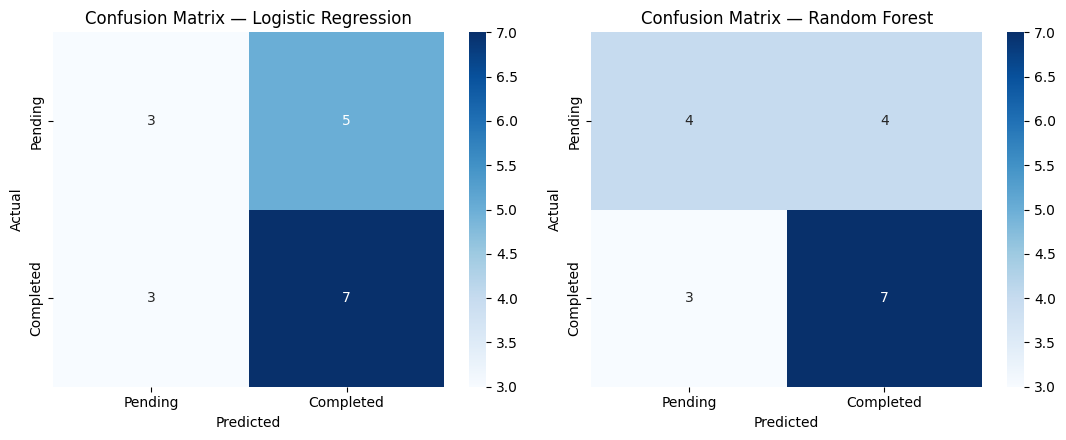

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name, y_pred in zip(axes, ["Logistic Regression", "Random Forest"], [y_pred_lr, y_pred_rf]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pending", "Completed"], yticklabels=["Pending", "Completed"])
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


**What this tells us:** Both confusion matrices show how many Completed/Pending appointments were classified correctly vs. incorrectly. With such a small test set (a handful of rows), don't over-interpret small differences — the goal here is to demonstrate the *pipeline*, not to claim production accuracy.

Best model by F1-score on this test set: Random Forest

Feature importances (Random Forest):
experience_years      0.341326
age                   0.237875
specialization_enc    0.230075
day_of_week_enc       0.155958
gender_enc            0.034766
dtype: float64


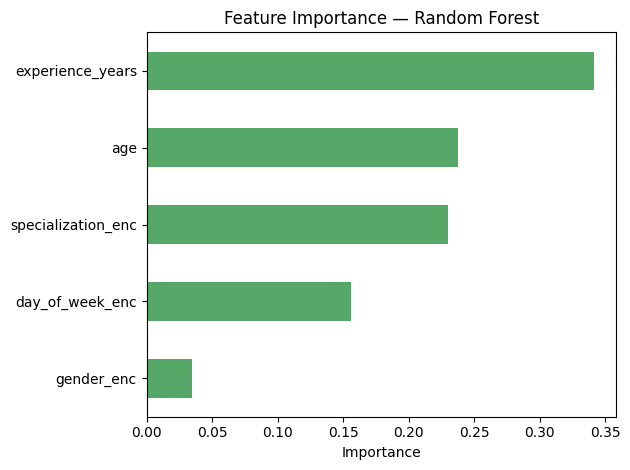

In [27]:
best_model_name = results.loc[results["F1-score"].idxmax(), "Model"]
print(f"Best model by F1-score on this test set: {best_model_name}")

if best_model_name == "Random Forest":
    importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print("\nFeature importances (Random Forest):")
    print(importances)

    plt.figure()
    importances.plot(kind="barh", color="#55A868")
    plt.title("Feature Importance — Random Forest")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    coefs = pd.Series(log_reg.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)
    print("\nStandardized coefficients (Logistic Regression):")
    print(coefs)


**What this tells us:** This shows which factors the model leans on most when predicting completion. On a small synthetic dataset like this, feature importances should be treated as illustrative — with real historical data (hundreds/thousands of appointments), this view becomes genuinely actionable for identifying real risk factors for no-shows.

## 9. Exporting the Model (`.pkl`)
We export everything the deployed app (e.g. a Streamlit app) needs to make predictions on brand-new appointment data:
- The trained model (whichever performed best)
- The `StandardScaler` (only needed if the deployed model is Logistic Regression)
- The three `LabelEncoder`s (to convert raw text input — gender, specialization, day of week — into the same numeric codes used in training)
- The exact list/order of feature columns

All of this is bundled into a single dictionary and saved as one `.pkl` file with `joblib`, so the Streamlit app only needs to load one file.


In [28]:
final_model = rf if best_model_name == "Random Forest" else log_reg

deployment_bundle = {
    "model": final_model,
    "model_name": best_model_name,
    "scaler": scaler,                # only used if model_name == "Logistic Regression"
    "label_encoders": {
        "gender": le_gender,
        "specialization": le_spec,
        "day_of_week": le_day,
    },
    "feature_columns": feature_cols,
    "specialization_options": sorted(model_df["specialization"].unique().tolist()),
    "gender_options": sorted(model_df["gender"].unique().tolist()),
}

joblib.dump(deployment_bundle, "appointment_status_model.pkl")
print("Saved -> appointment_status_model.pkl")
print("Bundle keys:", list(deployment_bundle.keys()))


Saved -> appointment_status_model.pkl
Bundle keys: ['model', 'model_name', 'scaler', 'label_encoders', 'feature_columns', 'specialization_options', 'gender_options']


**How the Streamlit app will use this file:**
```python
bundle = joblib.load("appointment_status_model.pkl")
model = bundle["model"]
# encode new patient/doctor input using bundle["label_encoders"], scale if needed with bundle["scaler"],
# then model.predict(...) to flag high-risk (likely-Pending) appointments.
```


## 10. Executive Summary

**Objective:** Build an end-to-end pipeline on the Hospital Management dataset (Doctors, Patients, Appointments) — clean the data, explore it, and train a model that predicts whether a scheduled appointment will be *Completed* or remain *Pending*, so a clinic could proactively follow up on at-risk appointments.

**Data:** 15 doctors, 36 patients, 72 appointments (Nov 2024 – Feb 2025). The raw files contained the literal text `"NULL"` instead of true missing values in several columns (doctor experience, patient `doctor_id`/contact number, appointment status) — these were converted to proper missing values and handled with column-appropriate strategies (median imputation for experience, exclusion for unmodelable gaps).

**Key EDA findings:**
- Appointment status is roughly balanced between Completed and Pending — no major class imbalance.
- Patient population spans a wide adult age range (mid-20s to late-70s), gender split close to even.
- Doctor workload is evenly distributed (4–6 appointments each) — no bottleneck doctor in this sample.
- Completion rate differs somewhat by specialization, but sample sizes per specialty are too small to draw firm conclusions.
- No meaningful correlation between doctor experience and patient age.
- Appointment volume was fairly steady across the observed months.

**Modeling:** Logistic Regression and Random Forest classifiers were trained on patient age, gender, doctor specialization, doctor experience, and appointment day-of-week to predict completion status. Both were evaluated on a held-out test split using Accuracy, Precision, Recall and F1-score; the stronger performer was selected and exported.

**Caveat:** This dataset is small (72 appointments) and appears synthetically generated, so model metrics should be read as a **proof of the pipeline**, not a production-grade result. The same notebook will scale directly to a real, larger appointments history — more data would meaningfully improve both the reliability of the EDA patterns and the model's predictive power.

**Deliverable:** `appointment_status_model.pkl` — a single deployment-ready bundle (model + encoders + scaler + feature list) ready to be loaded into a Streamlit app for live predictions.

**Suggested next step:** Build the Streamlit interface — input fields for patient age/gender, doctor specialization/experience, and appointment day — that loads this `.pkl` and returns a Completed/Pending risk prediction.
